In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from shapely.geometry import MultiPoint, Point, Polygon, shape
from shapely.ops import unary_union
import json
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


from feems.utils import prepare_graph_inputs
from feems import SpatialGraph, Viz
from feems.cross_validation import run_cv

UP = Path(r'/Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages/data')
GRID_RES = "grid_100.shp"                
DISC_R   = 1.25 
USE_IDF  = True                          # IDF-weight columns instead of Patterson scaling

In [7]:
# Loading Data

ruhlen = pd.read_csv(UP / "RUHLENdf_PH.csv")
idf    = pd.read_csv(UP / "phoneme_freq_ruhlen_austronesian.csv")

PH_ALL = [c for c in ruhlen.columns if c.startswith("phoneme_")]
print(ruhlen.shape, "|", len(PH_ALL), "phoneme cols")
print(ruhlen.Language_type.value_counts())

(198, 734) | 728 phoneme cols
Language_type
Unrelated Language      137
Philippine Language      58
Language of Interest      3
Name: count, dtype: int64


In [8]:
# Subset to the 58 Philippine Languages
ph = ruhlen.loc[ruhlen.Language_type == "Philippine Language"].reset_index(drop=True)

coord = ph[["longitude", "latitude"]].to_numpy()      # FEEMS wants (lon, lat) — same order as EEMS .coord
assert coord.shape == (58, 2)
print("lon", coord[:,0].min().round(2), "..", coord[:,0].max().round(2),
      "| lat", coord[:,1].min().round(2), "..", coord[:,1].max().round(2))
print("duplicate coords:", len(coord) - len(np.unique(coord, axis=0)))

lon 118.52 .. 126.16 | lat 5.4 .. 20.38
duplicate coords: 1


In [9]:
# Feature filtering 

X_all  = ph[PH_ALL].to_numpy(dtype=float)
col_n  = X_all.sum(axis=0)
n_lang = X_all.shape[0]

keep    = (col_n > 0) & (col_n < n_lang)          # drop zero-variance columns
PH_KEEP = [c for c, k in zip(PH_ALL, keep) if k]
X       = X_all[:, keep]

print(f"total {len(PH_ALL)} | all-zero {(col_n==0).sum()} | all-one {(col_n==n_lang).sum()} | retained {keep.sum()}")
print("retained freq spectrum:", np.sort(X.sum(axis=0))[::-1].astype(int))

Xc = X - X.mean(axis=0)
print("rank(centred X):", int((np.linalg.svd(Xc, compute_uv=False) > 1e-10).sum()), "of", X.shape[1])

total 728 | all-zero 679 | all-one 10 | retained 39
retained freq spectrum: [57 57 56 56 54 51 45 35 31 20 20 17 17 17 16 11  7  7  7  6  5  5  4  4
  3  3  3  2  2  2  2  2  1  1  1  1  1  1  1]
rank(centred X): 36 of 39


In [10]:
# Pseudo Genotype Matrix for Phoneme Data

geno = X * 2.0                                     # {0,1} presence -> {0,2} dosage

if USE_IDF:
    w_idf = idf.set_index("phoneme")["IDF"].reindex(PH_KEEP).to_numpy()
    assert not np.isnan(w_idf).any()
    geno = geno * w_idf                            # IDF, applied manually
    SCALE_SNPS = False                             # do NOT also Patterson-scale

print(geno.shape, "| range", geno.min().round(3), geno.max().round(3), "| NaN:", np.isnan(geno).any())

(58, 39) | range 0.0 9.919 | NaN: False


In [49]:
with open(UP / "countries.geojson") as f:
    countries = json.load(f)

ph_feat = next(f for f in countries["features"] if f["properties"].get("name") == "Philippines")
ph_geom = shape(ph_feat["geometry"])

COAST_BUF = 0.8   # minimum buffer that merges the archipelago into one connected piece —
                  # do not lower without re-checking; 0.7 leaves Sulu Archipelago isolated
habitat = ph_geom.buffer(COAST_BUF).simplify(0.1)
assert habitat.geom_type == "Polygon", f"still {len(habitat.geoms)} pieces — raise COAST_BUF"
outer = np.array(habitat.exterior.coords)
print("outer vertices:", len(outer))

NameError: name 'shape' is not defined

In [ ]:
import feems
import os
print(os.path.join(os.path.dirname(feems.__file__), "data", GRID_RES))

/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/data/grid_100.shp


In [ ]:
import feems
import os

grid_path = os.path.join(os.path.dirname(feems.__file__), "data", GRID_RES)
assert os.path.exists(grid_path), f"grid shapefile not found at {grid_path}"

outer, edges, grid, ipmap = prepare_graph_inputs(
    coord=coord,
    ggrid=grid_path,
    translated=False,
    buffer=0,
    outer=outer,       # from Cell 6 — the union-of-discs polygon
)

# --- connectivity: resistance distance is undefined across disconnected components ---
G = nx.Graph()
G.add_nodes_from(range(grid.shape[0]))
G.add_edges_from([(a - 1, b - 1) for a, b in edges])   # edges are 1-indexed
n_components = nx.number_connected_components(G)

print(f"grid nodes: {grid.shape[0]}  |  edges: {edges.shape[0]}  |  components: {n_components}")
assert n_components == 1, (
    f"habitat fragmented into {n_components} disconnected pieces — raise DISC_R in Cell 1"
)

# --- coverage: every language must land inside the node mesh, not just the polygon ---
node_hull = MultiPoint([tuple(g) for g in grid]).convex_hull
stranded = [i for i, c in enumerate(coord) if not node_hull.contains(Point(c))]
print(f"stranded languages: {len(stranded)}")
assert len(stranded) == 0, f"{len(stranded)} language(s) fall outside the node mesh: {stranded}"

# --- occupancy sanity check ---
occ_idx = np.unique(ipmap)
occ_counts = np.array([np.sum(ipmap == i) for i in occ_idx])
print(f"occupied demes: {len(occ_idx)} of {grid.shape[0]}  "
      f"({(grid.shape[0]-len(occ_idx))/grid.shape[0]*100:.0f}% unobserved)")
print(f"languages per occupied deme — max: {occ_counts.max()}, median: {int(np.median(occ_counts))}")

grid nodes: 78  |  edges: 174  |  components: 1
stranded languages: 0
occupied demes: 31 of 78  (60% unobserved)
languages per occupied deme — max: 7, median: 1


In [22]:
# SpatialGraph + occupancy check

sp_graph = SpatialGraph(geno, coord, grid, edges, scale_snps=SCALE_SNPS)

occ = np.array([sp_graph.nodes[n]["n_samples"] for n in range(len(sp_graph.nodes))])
occ = occ[occ > 0]
print("observed demes:", sp_graph.n_observed_nodes, "| max languages/deme:", occ.max(), "| median:", np.median(occ))
print("languages per occupied deme:", np.sort(occ)[::-1])
print("singleton demes:", (occ == 1).sum(), "of", len(occ))

Initializing graph...
Computing graph attributes...
Assigning samples to nodes...done.
observed demes: 31 | max languages/deme: 7 | median: 1.0
languages per occupied deme: [7 5 4 4 4 3 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
singleton demes: 19 of 31


In [23]:
# Patching run_cv bugged feems

import numpy as np
from copy import deepcopy
import feems.cross_validation as cv_mod
from feems.objective import Objective, comp_mats
from feems.spatial_graph import query_node_attributes

def predict_snps_patched(sp_graph, sp_graph_train, sp_graph_test):
    obj = Objective(sp_graph)
    obj.sp_graph.comp_graph_laplacian(sp_graph_train.w)
    fit_cov, _, _ = comp_mats(obj)

    n_snps = sp_graph.n_snps
    if sp_graph.scale_snps:
        mu_f = np.sqrt(sp_graph.mu * (1 - sp_graph.mu))   # original behaviour, untouched
    else:
        mu_f = np.ones(n_snps)                             # frequencies already in natural units

    frequencies_ns = sp_graph.frequencies * mu_f
    mu0 = frequencies_ns.mean(axis=0) / 2
    mu_frequencies = 2 * mu0 / mu_f
    frequencies = deepcopy(sp_graph.frequencies)

    ids = np.empty(sp_graph.n_observed_nodes, dtype=bool)
    permuted_idx = query_node_attributes(sp_graph, "permuted_idx")
    permuted_idx_train = query_node_attributes(sp_graph_train, "permuted_idx")
    for i, idx in enumerate(permuted_idx[: sp_graph.n_observed_nodes]):
        ids[i] = idx in permuted_idx_train[: sp_graph_train.n_observed_nodes]
    train_ids = np.argwhere(ids).reshape(-1)
    test_ids  = np.argwhere(~ids).reshape(-1)

    cov_te_tr = fit_cov[np.ix_(test_ids, train_ids)]
    cov_tr_tr = fit_cov[np.ix_(train_ids, train_ids)]
    pred_frequencies = mu_frequencies + cov_te_tr @ np.linalg.solve(
        cov_tr_tr, frequencies[train_ids, :] - mu_frequencies
    )
    l2_err = np.linalg.norm(
        pred_frequencies * mu_f - frequencies[test_ids] * mu_f
    )
    return pred_frequencies, l2_err

cv_mod.predict_snps = predict_snps_patched   # redirect run_cv's internal call


 fold:  0
iteration lambda=20/20 alpha=1/1
 fold:  1
iteration lambda=20/20 alpha=1/1
 fold:  2
iteration lambda=20/20 alpha=1/1
 fold:  3
iteration lambda=20/20 alpha=1/1
 fold:  4
iteration lambda=20/20 alpha=1/1
 fold:  5
iteration lambda=20/20 alpha=1/1
 fold:  6
iteration lambda=20/20 alpha=1/1
 fold:  7
iteration lambda=20/20 alpha=1/1
 fold:  8
iteration lambda=20/20 alpha=1/1
 fold:  9
iteration lambda=20/20 alpha=1/1
 fold:  10
iteration lambda=20/20 alpha=1/1
 fold:  11
iteration lambda=20/20 alpha=1/1
 fold:  12
iteration lambda=20/20 alpha=1/1
 fold:  13
iteration lambda=20/20 alpha=1/1
 fold:  14
iteration lambda=20/20 alpha=1/1
 fold:  15
iteration lambda=20/20 alpha=1/1
 fold:  16
iteration lambda=20/20 alpha=1/1
 fold:  17
iteration lambda=20/20 alpha=1/1
 fold:  18
iteration lambda=20/20 alpha=1/1
 fold:  19
iteration lambda=20/20 alpha=1/1
 fold:  20
iteration lambda=20/20 alpha=1/1
 fold:  21
iteration lambda=20/20 alpha=1/1
 fold:  22
iteration lambda=20/20 alpha=1

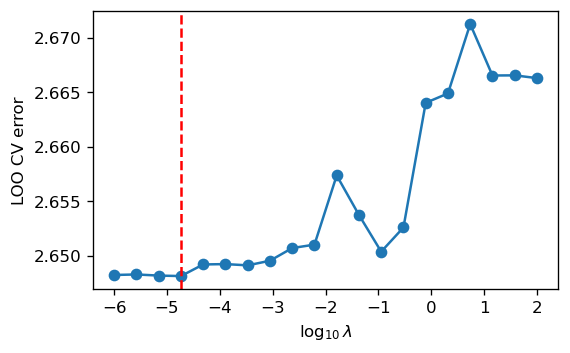

lamb_cv = 1.8329807108324375e-05


In [24]:
lamb_grid = np.geomspace(1e-6, 1e2, 20)[::-1]

cv_err = run_cv(sp_graph, lamb_grid, n_folds=sp_graph.n_observed_nodes, factr=1e10)
mean_cv_err = np.mean(cv_err, axis=0)
lamb_cv = float(lamb_grid[np.argmin(mean_cv_err)])

fig, ax = plt.subplots(figsize=(5,3), dpi=120)
ax.plot(np.log10(lamb_grid), mean_cv_err, "o-")
ax.axvline(np.log10(lamb_cv), ls="--", c="r")
ax.set_xlabel(r"$\log_{10}\lambda$"); ax.set_ylabel("LOO CV error")
plt.show()

print("lamb_cv =", lamb_cv)
if np.argmin(mean_cv_err) in (0, len(lamb_grid)-1):
    print("WARNING: minimum at grid boundary — widen lamb_grid")

In [25]:
sp_graph.fit(lamb=lamb_cv, optimize_q=None)

print("edges:", len(sp_graph.w))
print("log10(w/wbar):  min %.3f  max %.3f  sd %.3f" % (
    np.log10(sp_graph.w / sp_graph.w.mean()).min(),
    np.log10(sp_graph.w / sp_graph.w.mean()).max(),
    np.log10(sp_graph.w / sp_graph.w.mean()).std()))

edges: 174
log10(w/wbar):  min -6.585  max 0.546  sd 2.092


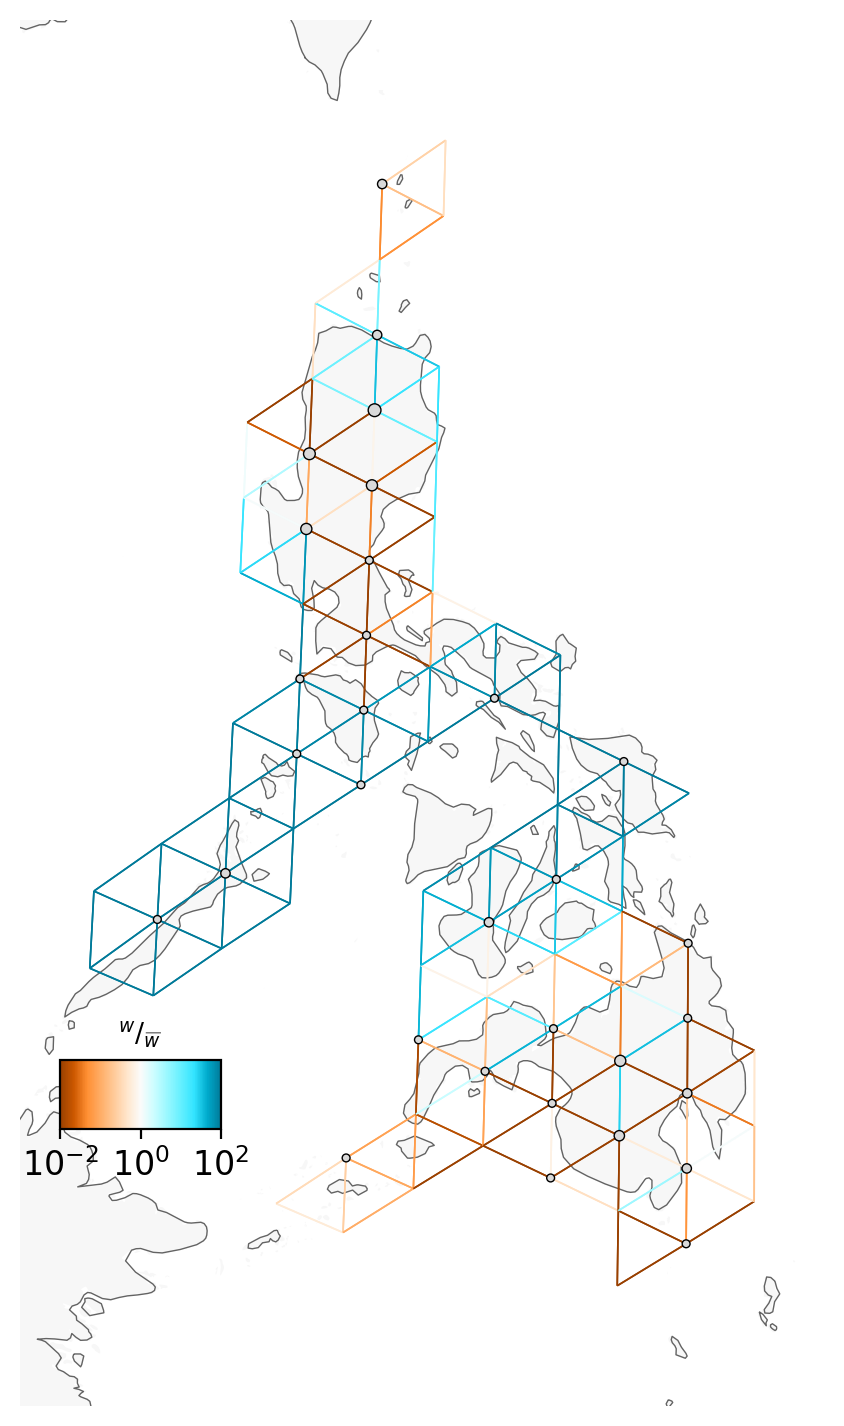

In [26]:
projection = ccrs.EquidistantConic(central_longitude=122.0, central_latitude=13.0)

fig = plt.figure(figsize=(7,9), dpi=200)
ax  = fig.add_subplot(1,1,1, projection=projection)
v = Viz(ax, sp_graph, projection=projection, edge_width=0.6,
        edge_alpha=1, edge_zorder=100, sample_pt_size=12,
        obs_node_size=8, sample_pt_color="black", cbar_font_size=8)
v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False)
v.draw_edge_colorbar()
plt.show()

In [28]:

n_nodes = sp_graph.node_pos.shape[0]
edge_arr = np.array(sp_graph.edges)          # (n_edges, 2), 0-indexed
log_w = np.log10(sp_graph.w / sp_graph.w.mean())

node_val = np.zeros(n_nodes)
node_cnt = np.zeros(n_nodes)
for k in range(len(edge_arr)):
    i, j = edge_arr[k]
    node_val[i] += log_w[k]; node_cnt[i] += 1
    node_val[j] += log_w[k]; node_cnt[j] += 1

node_val = np.divide(node_val, node_cnt, out=np.full(n_nodes, np.nan), where=node_cnt > 0)
print("isolated nodes (no edges, will be NaN):", np.isnan(node_val).sum())

isolated nodes (no edges, will be NaN): 0


In [32]:
triang = mtri.Triangulation(sp_graph.node_pos[:,0], sp_graph.node_pos[:,1])
interp = mtri.LinearTriInterpolator(triang, node_val)

RES = 300  # raster resolution; raise for a smoother/finer export
lon_g = np.linspace(outer[:,0].min(), outer[:,0].max(), RES)
lat_g = np.linspace(outer[:,1].min(), outer[:,1].max(), int(RES*4/3))
LON, LAT = np.meshgrid(lon_g, lat_g)
Z = interp(LON, LAT)

poly = Polygon(outer)   # reuse the exact outer polygon from Cell 6 — same habitat, same graph
mask = np.array([[poly.contains(Point(LON[i,j], LAT[i,j])) for j in range(LON.shape[1])]
                  for i in range(LON.shape[0])])
Z = np.ma.array(Z, mask=~mask | np.ma.getmaskarray(Z))

print("valid raster fraction:", (~np.ma.getmaskarray(Z)).mean().round(3))

valid raster fraction: 0.419


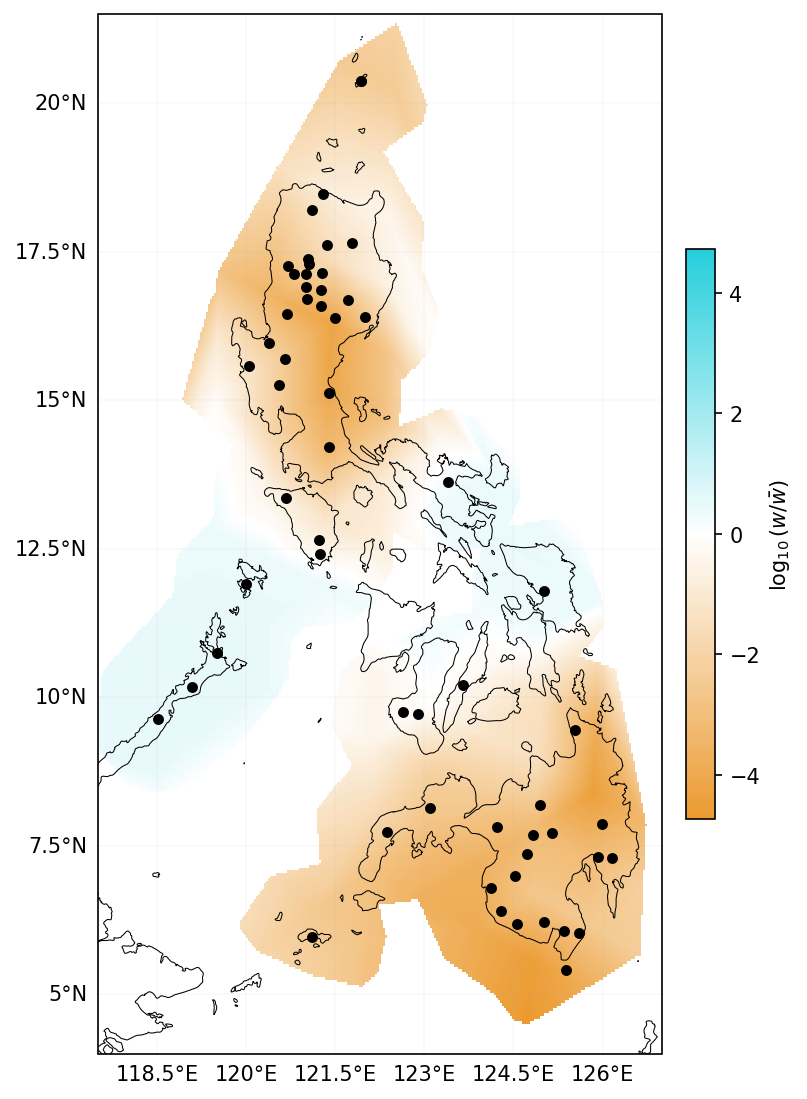

In [34]:
# EEMS-convention colormap: orange = low conductance (barrier), cyan = high
feems_cmap = LinearSegmentedColormap.from_list("feems_oc", ["#E8890C", "#FFFFFF", "#00C6D6"])

# symmetric about 0 so white always means "at the mean" — do NOT let it auto-center
vmax = float(np.nanmax(np.abs(Z)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig = plt.figure(figsize=(7, 9), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([117.5, 127.0, 4.0, 21.5], crs=ccrs.PlateCarree())

pc = ax.pcolormesh(LON, LAT, Z, cmap=feems_cmap, norm=norm,
                   shading="auto", alpha=0.85, transform=ccrs.PlateCarree(), zorder=1)

ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.5, edgecolor="black", zorder=5)

# sample locations
ax.scatter(coord[:, 0], coord[:, 1], s=18, c="black",
           transform=ccrs.PlateCarree(), zorder=10)

cb = fig.colorbar(pc, ax=ax, fraction=0.035, pad=0.03)
cb.set_label(r"$\log_{10}(w/\bar{w})$")

gl = ax.gridlines(draw_labels=True, lw=0.2, alpha=0.3)
gl.top_labels = False; gl.right_labels = False
plt.show()

In [40]:
edge_arr = np.array(sp_graph.edges)          # 0-indexed, (n_edges, 2)

edgew_df = pd.DataFrame({
    "node_i": edge_arr[:, 0],
    "node_j": edge_arr[:, 1],
    "w": sp_graph.w,
    "log10_w_ratio": np.log10(sp_graph.w / sp_graph.w.mean()),
})
edgew_df.to_csv("edgew_phoneme.csv", index=False)

nodepos_df = pd.DataFrame({
    "lon": sp_graph.node_pos[:, 0],
    "lat": sp_graph.node_pos[:, 1],
    "n_samples": [sp_graph.nodes[n]["n_samples"] for n in range(len(sp_graph.nodes))],
})
nodepos_df.to_csv(UP/"nodepos_phoneme.csv", index=False)

print(edgew_df.shape, nodepos_df.shape)

(174, 4) (78, 3)


In [41]:
valid = ~np.ma.getmaskarray(Z)
raster_df = pd.DataFrame({
    "lon": LON[valid],
    "lat": LAT[valid],
    "log_w_ratio": Z[valid].data,
})
raster_df.to_csv(UP/"phoneme_surface_raster.csv", index=False)
print(raster_df.shape)

(50296, 3)


In [43]:
import json

meta = {
    "grid_res": GRID_RES,
    "disc_r": DISC_R,
    "n_nodes": int(grid.shape[0]),
    "n_edges": int(edges.shape[0]),
    "n_observed_nodes": int(sp_graph.n_observed_nodes),
    "scale_snps": bool(SCALE_SNPS),
    "use_idf": bool(USE_IDF),
    "optimize_q": None,
    "lamb_cv": float(lamb_cv),
    "n_features_retained": int(len(PH_KEEP)),
}
with open(UP/"phoneme_feems_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(meta)

{'grid_res': 'grid_100.shp', 'disc_r': 1.25, 'n_nodes': 78, 'n_edges': 174, 'n_observed_nodes': 31, 'scale_snps': False, 'use_idf': True, 'optimize_q': None, 'lamb_cv': 1.8329807108324375e-05, 'n_features_retained': 39}
